In [1]:
import os
import numpy as np
import scvelo as scv
import scanpy as sc
import pandas as pd
import topovelo as tpv
import matplotlib.pyplot as plt

In [2]:
DATA_DIR = ''
DATA_NAME = 'slide-tag-mouse-brain'

In [3]:
adata = sc.read(os.path.join(DATA_DIR, f'{DATA_NAME}_pp.h5ad'))

In [4]:
FIG_DIR='./figures/slide-tag-mouse-brain'
MODEL_DIR = './checkpoints/slide-tag-mouse-brain'
DATA_DIR = ''

# (Optional) Select spatially highly variable genes
We already performed this step.

In [ ]:
df_gene = pd.read_csv('')

In [ ]:
variable_genes = df_gene.index.to_numpy().astype(str)
in_adata = np.array([x in adata.var_names for x in variable_genes])
variable_genes = variable_genes[in_adata]

In [ ]:
adata._inplace_subset_var(variable_genes[:500])

In [ ]:
scv.pp.filter_genes(adata, min_shared_counts=10)
scv.pp.normalize_per_cell(adata)
scv.pp.log1p(adata)
scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
scv.tl.umap(adata)

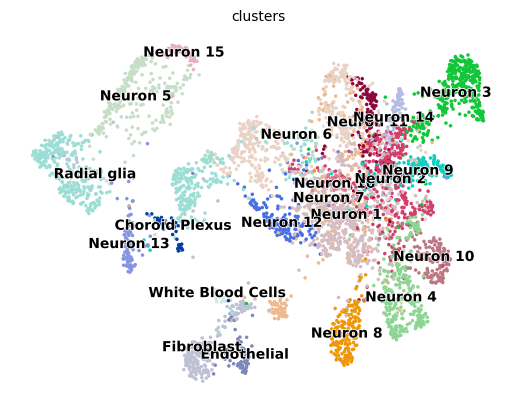

In [16]:
scv.pl.scatter(adata)

# (Optional) Build a spatial graph

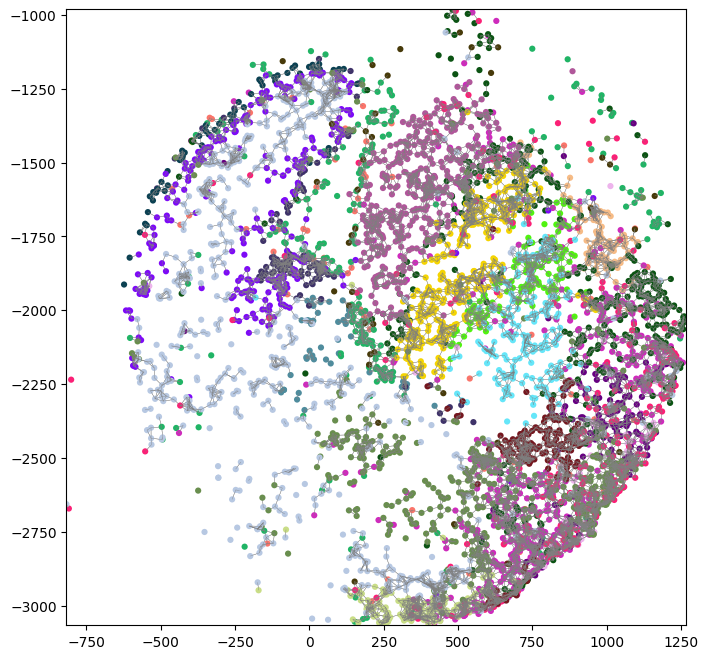

In [12]:
# tpv.build_spatial_graph(adata, 'X_spatial', method='KNN', dist_cutoff='auto', radius=50.0)
tpv.plotting.plot_spatial_graph(adata, width=8)

# TopoVelo (GAT)

In [5]:
figure_path = f'{FIG_DIR}/gat'
model_path = f'{MODEL_DIR}/gat'

vae = tpv.VAE(adata, 
              tmax=20, 
              dim_z=10, 
              spatial_graph_key='spatial_graph',
              device='cuda:0',
              graph_decoder=True,
              attention=True)
config = {
    'batch_size':128,
    'n_epochs': 2000,
}
vae.train(adata,
          adata.obsp['spatial_graph'],
          "X_spatial",
          config=config,
          plot=False,
          figure_path=figure_path,
          embed='spatial')
vae.save_model(model_path, 'encoder', 'decoder')
vae.save_anndata(adata, 'gat', DATA_DIR, file_name="adata_out.h5ad")

Estimating ODE parameters...


  0%|          | 0/486 [00:00<?, ?it/s]

  0%|          | 0/486 [00:00<?, ?it/s]

Reinitialize the regular ODE parameters based on estimated global latent time.


  0%|          | 0/486 [00:00<?, ?it/s]

*********               Creating a Graph Dataset              *********
*********                      Finished.                      *********
--------------------------- Train a TopoVelo ---------------------------
*********                 Creating optimizers                 *********
*********                      Finished.                      *********
*********                    Start training                   *********
*********                      Stage  1                       *********
*********       Stage 1: Early Stop Triggered at epoch 266.       *********
Summary: 
Train ELBO = -55.697
Test ELBO = -72.667
Total Time =   0 h : 12 m : 10 s

*********                      Stage  2                       *********


Calculating KNN:   0%|          | 0/4623 [00:00<?, ?it/s]

Stage 2: Early Stop Triggered at round 4.
Final: Train ELBO = 235.359,	Test ELBO = 215.177
*********              Finished. Total Time =   0 h : 16 m : 40 s             *********


---   Plotting  Results   ---
Computing a spatial graph using KNN on spatial with k=50
computing neighbors
    finished (0:00:03) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing velocity graph (using 2/32 cores)


  0%|          | 0/4623 [00:00<?, ?cells/s]

    finished (0:00:11) --> added 
    'gat_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'gat_velocity_spatial', embedded velocity vectors (adata.obsm)


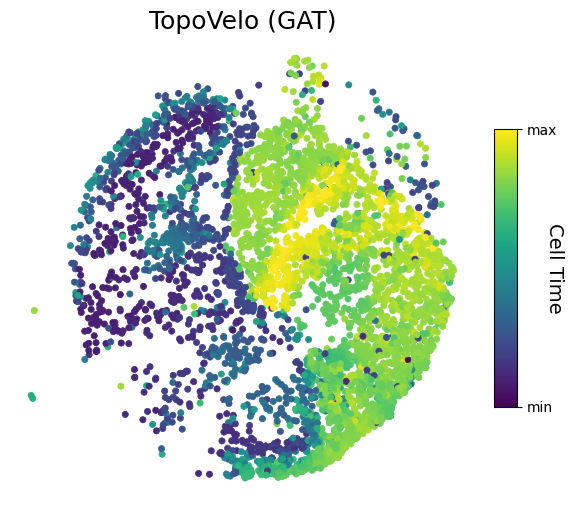

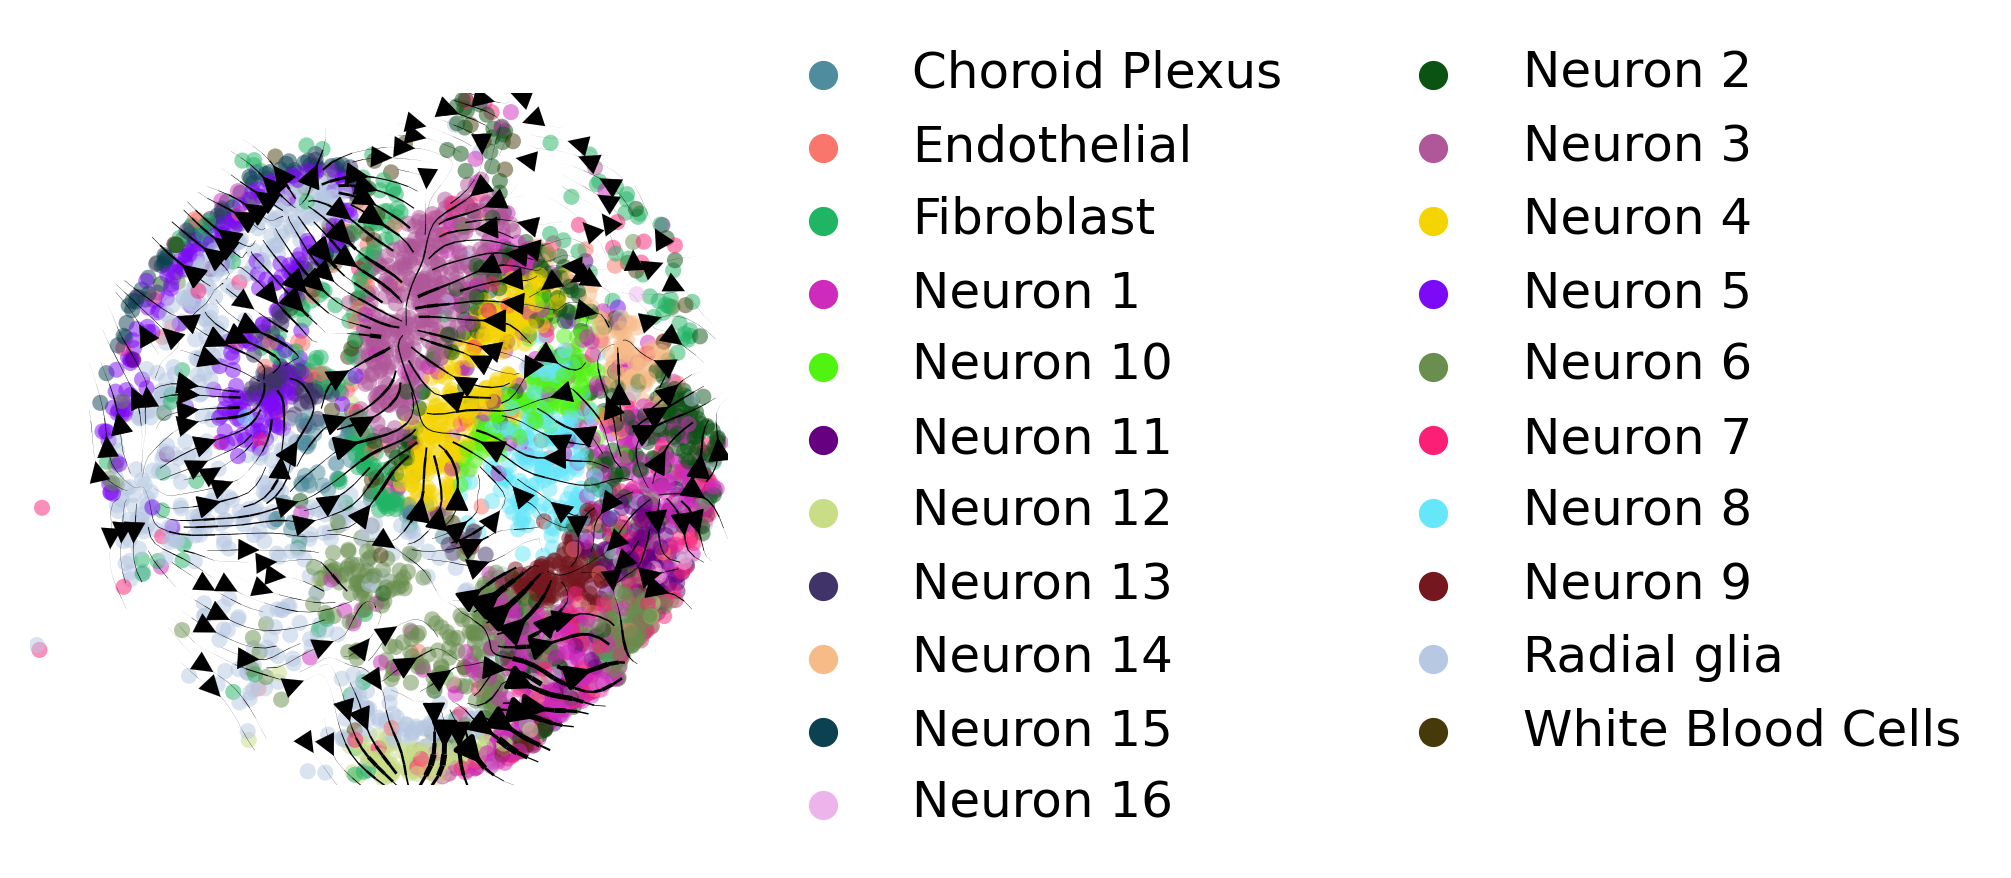

Recovering the original KNN graph from .uns


In [6]:
stream_plot_config = {
    'width': 3,
    'markersize': 60,
    'density': 2,
    'linewidth': 1,
}
_ = tpv.post_analysis(
    adata,
    DATA_NAME,
    ['TopoVelo (GAT)'],
    ['gat'],
    plot_type=['cell velocity', 'time'],
    stream_plot_config=stream_plot_config,
    dpi=300
)